### Sliding of Retaining wall
### Usually type B

In [2]:
import numpy as np
from itertools import product
from math import radians, degrees, sin, cos, tan, sqrt, atan
from scipy.stats import t
from scipy.stats import linregress
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Here we set some parameters
n = 30
L_wall = 3.5
H = 5
beta = 5
gamma_wall = 23.6
gamma1 = 20
phi1_mean = 30
phi1_cov = 0.1
phi2_mean = 30 
phi2_cov = 0.1
c_mean = 20 
c_cov = 0.4
case = 2


def calculate_characteristic_value(mean, cov, theta, L, case, n) :
    """
    Calculate the characteristic value (X_k) based on spatial variability.
    
    Parameters:
    - mean: Mean value of the property.
    - cov: Coefficient of variation (V_X).
    - theta: Scale of fluctuation (spatial variability).
    - L: averaging length
    - case: "1" (V_X known), "2" (V_X unknown), or "3" (V_X assumed).
    - n: Number of samples

    Returns:
    - X_k: Characteristic value.
    """
    # Adjust gamma_sq based on estimate type (Vanmarcke's)
    if L<= theta:
        gamma_sq = 1  # Case B,  Inferior or Fractile (fully sensitive)
    else:  # Case C, intermediate; When theta/L gets so small, it eventually tends to be 0, which is the case A (mean value - insensitive to variability)
        gamma_sq = theta/L
    
    N95 = 1.645
    t95 =  t.ppf(0.95, n-1)

    # Compute k_n based on case and estimate type
    if case == "1"or case =="3":  # case 1, V_X known; case 3, V_X unknown
        k_n = N95 * sqrt(gamma_sq + 1 / n)
    else:  # case 2, V_X unknown
        k_n = t95 * sqrt(gamma_sq + 1 / n)

    # Calculate characteristic value
    X_k = mean * (1 - k_n * cov)   

    return X_k

def calculate_limit_state_function_G(theta_phi, theta_c, n, L_wall,  H, beta, gamma_wall, gamma1, 
                                     phi1_mean, phi1_cov,phi2_mean, phi2_cov,c_mean, c_cov,case):
    
    B = L_wall /1.25
    
    alpha = degrees(atan((L_wall - B) / H))
    G1 = gamma_wall * B * H  # rectangle part
    G2 = gamma_wall * (L_wall - B) * H / 2  # triangle part
    
    L_infl=L_wall

    # Characteristic values
    phi1_k = calculate_characteristic_value(phi1_mean, phi1_cov, theta_phi, L_infl, case, n)
    phi2_k = calculate_characteristic_value(phi2_mean, phi2_cov, theta_phi, L_infl, case, n)
    c_k = calculate_characteristic_value(c_mean, c_cov, theta_c, L_infl, case, n)
    
    # Design values
    #phi1_d = degrees(atan(tan(radians(phi1_k)) / gamma_phi))
    #phi2_d = degrees(atan(tan(radians(phi2_k)) / gamma_phi))
    #c_d = c_k / gamma_c

    # wall and soil friction
    delta1 = (2/3) * phi1_k
    delta2 = (2/3) * phi2_k
    
    # Active pressure coefficient
    numerator = cos(radians(phi1_k - alpha))
    denom_part1 = cos(radians(alpha))
    denom_part2 = sqrt(
        (sin(radians(phi1_k + delta1)) * sin(radians(phi1_k - beta))) /
        (cos(radians(alpha - beta)) * cos(radians(alpha + delta1)))
    )
    K_agh = (numerator / (denom_part1 * (1 + denom_part2))) ** 2
    
    # Mindesterddruck: φ = 40°, c = 0
    phi_mindest = 40
    delta_mindest = (2/3) * phi_mindest
    numerator_m = cos(radians(phi_mindest - alpha))
    denom_m = cos(radians(alpha)) * (
        1 + sqrt(
            (sin(radians(phi_mindest + delta_mindest)) * sin(radians(phi_mindest - beta))) /
            (cos(radians(alpha - beta)) * cos(radians(alpha + delta_mindest)))
        )
    )
    K_mindest = (numerator_m / denom_m) ** 2
    E_ah_min = 0.5 * gamma1 * H**2 * K_mindest
    
    # Usual way of calculating earth pressure

    K_ach = (2 * cos(radians(alpha - beta)) * cos(radians(phi1_k)) * cos(radians(alpha + delta1))) / \
            (1 + sin(radians(phi1_k + delta1 + alpha - beta)) * cos(radians(alpha)))
    e_ach = -c_k * K_ach
    e_agh = gamma1 * H * K_agh

    e_ah = e_agh + e_ach
    
    # The depth where the positive stress starts to come in, c*K_ach = gamma1*z*K_agh
    z_start = c_k * K_ach / (K_agh * gamma1)

    # Calculating horizontal earth pressure, only the positive triangle is considered
    E_ah = e_ah * (H-z_start)/2

    # Compare with Mindesterdruck, take the higher value
    H_k = max(E_ah_min, E_ah)

    # Calculate vertical component
    E_av = H_k * tan(radians(delta1))    
    V_k = E_av + G1 + G2

    R_d = V_k * tan(radians(delta2)) /1.1   # BS-P, gamma_R,h
    H_d = H_k  * 1.35 # BS-P, gamma_G allgemiein ständige Einwirkungen

    G = R_d - H_d

    return G

# Test a range of theta                        
theta_range = np.linspace(0.05, 7, 350)  # Scale of fluctuation range (36,46) #!
min_G = float('inf')
worst_theta = None

for theta_phi, theta_c in product(theta_range, repeat=2):
    G = calculate_limit_state_function_G (theta_phi, theta_c, n, L_wall, H, beta, gamma_wall, gamma1,
                                          phi1_mean, phi1_cov, phi2_mean, phi2_cov, c_mean, c_cov, case)
    if G < min_G:
        min_G = G
        worst_theta = (theta_phi, theta_c)

print("Minimum G (most threshold):", round(min_G, 4))
print("Worst case SOF (φ, c):", worst_theta)

Minimum G (most threshold): 3.5113
Worst case SOF (φ, c): (3.5150429799426934, 3.5150429799426934)


In [3]:
theta_range

array([0.05      , 0.06991404, 0.08982808, 0.10974212, 0.12965616,
       0.1495702 , 0.16948424, 0.18939828, 0.20931232, 0.22922636,
       0.2491404 , 0.26905444, 0.28896848, 0.30888252, 0.32879656,
       0.3487106 , 0.36862464, 0.38853868, 0.40845272, 0.42836676,
       0.4482808 , 0.46819484, 0.48810888, 0.50802292, 0.52793696,
       0.547851  , 0.56776504, 0.58767908, 0.60759312, 0.62750716,
       0.6474212 , 0.66733524, 0.68724928, 0.70716332, 0.72707736,
       0.7469914 , 0.76690544, 0.78681948, 0.80673352, 0.82664756,
       0.8465616 , 0.86647564, 0.88638968, 0.90630372, 0.92621777,
       0.94613181, 0.96604585, 0.98595989, 1.00587393, 1.02578797,
       1.04570201, 1.06561605, 1.08553009, 1.10544413, 1.12535817,
       1.14527221, 1.16518625, 1.18510029, 1.20501433, 1.22492837,
       1.24484241, 1.26475645, 1.28467049, 1.30458453, 1.32449857,
       1.34441261, 1.36432665, 1.38424069, 1.40415473, 1.42406877,
       1.44398281, 1.46389685, 1.48381089, 1.50372493, 1.52363

Limit state function related to range of scale of fluctuation

[[48.04785186 47.73280563 47.43438903 ... 28.63770759 28.63770759
  28.63770759]
 [48.04785186 47.73280563 47.43438903 ... 28.63770759 28.63770759
  28.63770759]
 [48.04785186 47.73280563 47.43438903 ... 28.63770759 28.63770759
  28.63770759]
 ...
 [39.12400336 38.57715062 38.05828287 ...  3.51126649  3.51126649
   3.51126649]
 [39.12400336 38.57715062 38.05828287 ...  3.51126649  3.51126649
   3.51126649]
 [39.12400336 38.57715062 38.05828287 ...  3.51126649  3.51126649
   3.51126649]]


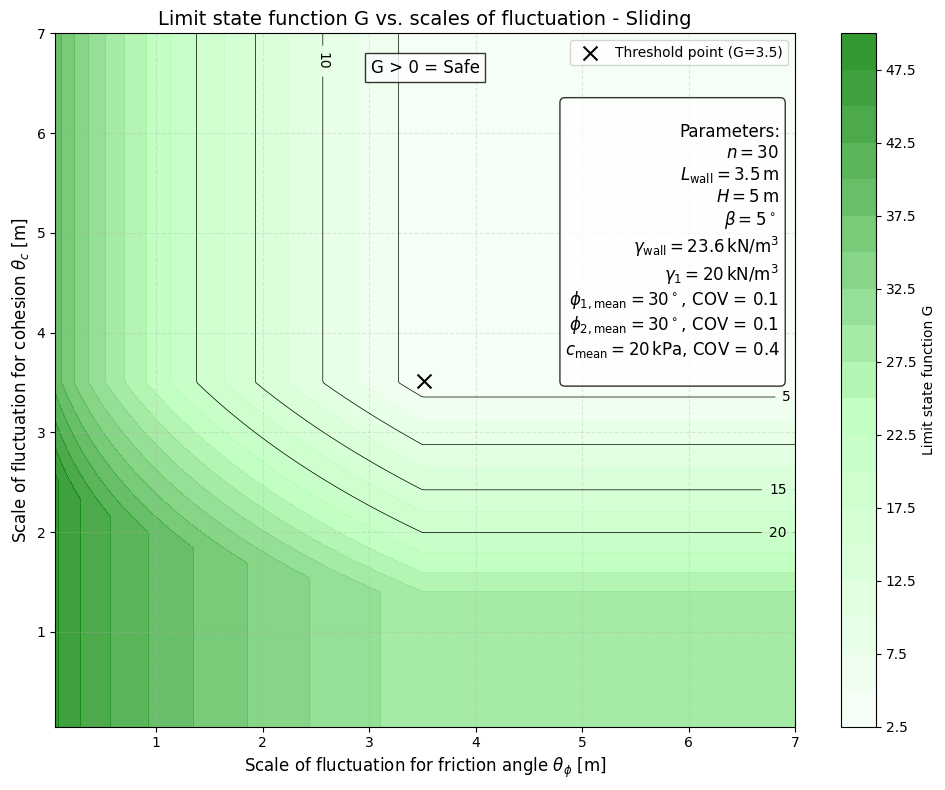

In [4]:
# Define parameter ranges
theta_phi_grid, theta_c_grid = np.meshgrid(theta_range, theta_range)

# Calculate G values for all combinations
G_values = np.zeros_like(theta_phi_grid)

#n=30
#L_infl = 3.5

for i in range(len(theta_range)):
    for j in range(len(theta_range)):
        G_values[i,j] = calculate_limit_state_function_G(
            theta_phi_grid[i,j], 
            theta_c_grid[i,j],
            n, L_wall, H, beta, gamma_wall, gamma1,
            phi1_mean, phi1_cov, phi2_mean, phi2_cov, c_mean, c_cov, case
        )

# Create the plot
plt.figure(figsize=(10, 8))

print (G_values)

# --- Make the white color at G=0 ---
G_max = np.max(np.abs(G_values))  # Largest magnitude (positive or negative)
vmin, vmax = -G_max, G_max  # Ensures zero is centered in the colormap

# Create custom colormap: red (unsafe) -> white (G=0) -> green (safe)
colors = [
    (0.5, 0.0, 0.0),  # Deep red
    (1.0, 0.7, 0.7),  # Light red (near zero)
    (1, 1, 1),        # Pure white at zero
    (0.7, 1.0, 0.7),  # Light green (near zero)
    (0.0, 0.5, 0.0)   # Deep green
]
cmap_custom = LinearSegmentedColormap.from_list('danger_safe', colors, N=512)


# Create contour plot
contour = plt.contourf(theta_phi_grid, theta_c_grid, G_values, levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
plt.colorbar(contour, label='Limit state function G')

# Add contour lines
CS = plt.contour(theta_phi_grid, theta_c_grid, G_values, 
                levels=[-5, 0, 5, 10, 15, 20], colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

# Highlight the threshold point (minimum G)
min_idx = np.unravel_index(np.argmin(G_values), G_values.shape)
plt.scatter(theta_phi_grid[min_idx], theta_c_grid[min_idx], 
           color='black', marker='x', s=100, label=f'Threshold point (G={G_values[min_idx]:.1f})')

# Formatting
plt.xlabel(r'Scale of fluctuation for friction angle $\theta_\phi$ [m]', fontsize=12)
plt.ylabel(r'Scale of fluctuation for cohesion $\theta_c$ [m]', fontsize=12)
plt.title('Limit state function G vs. scales of fluctuation - Sliding', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

# Add text annotation about safety
plt.text(0.5, 0.95, 'G > 0 = Safe', transform=plt.gca().transAxes,
        ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

#Add parameter list as text box (upper right corner)
param_text = rf"""
Parameters:
$n = {n}$ 
$L_{{\mathrm{{wall}}}} = {L_wall}\,\mathrm{{m}}$ 
$H = {H}\,\mathrm{{m}}$ 
$\beta = {beta}^\circ$ 
$\gamma_{{\mathrm{{wall}}}} = {gamma_wall}\,\mathrm{{kN/m^3}}$ 
$\gamma_1 = {gamma1}\,\mathrm{{kN/m^3}}$ 
$\phi_{{1,\mathrm{{mean}}}} = {phi1_mean}^\circ$, COV = {phi1_cov} 
$\phi_{{2,\mathrm{{mean}}}} = {phi2_mean}^\circ$, COV = {phi2_cov} 
$c_{{\mathrm{{mean}}}} = {c_mean}\,\mathrm{{kPa}}$, COV = {c_cov}
"""


plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()
plt.show()

Limit state function, related to normalized scale of fluctuation

[[48.04785186 47.73280563 47.43438903 ... 28.63770759 28.63770759
  28.63770759]
 [48.04785186 47.73280563 47.43438903 ... 28.63770759 28.63770759
  28.63770759]
 [48.04785186 47.73280563 47.43438903 ... 28.63770759 28.63770759
  28.63770759]
 ...
 [39.12400336 38.57715062 38.05828287 ...  3.51126649  3.51126649
   3.51126649]
 [39.12400336 38.57715062 38.05828287 ...  3.51126649  3.51126649
   3.51126649]
 [39.12400336 38.57715062 38.05828287 ...  3.51126649  3.51126649
   3.51126649]]


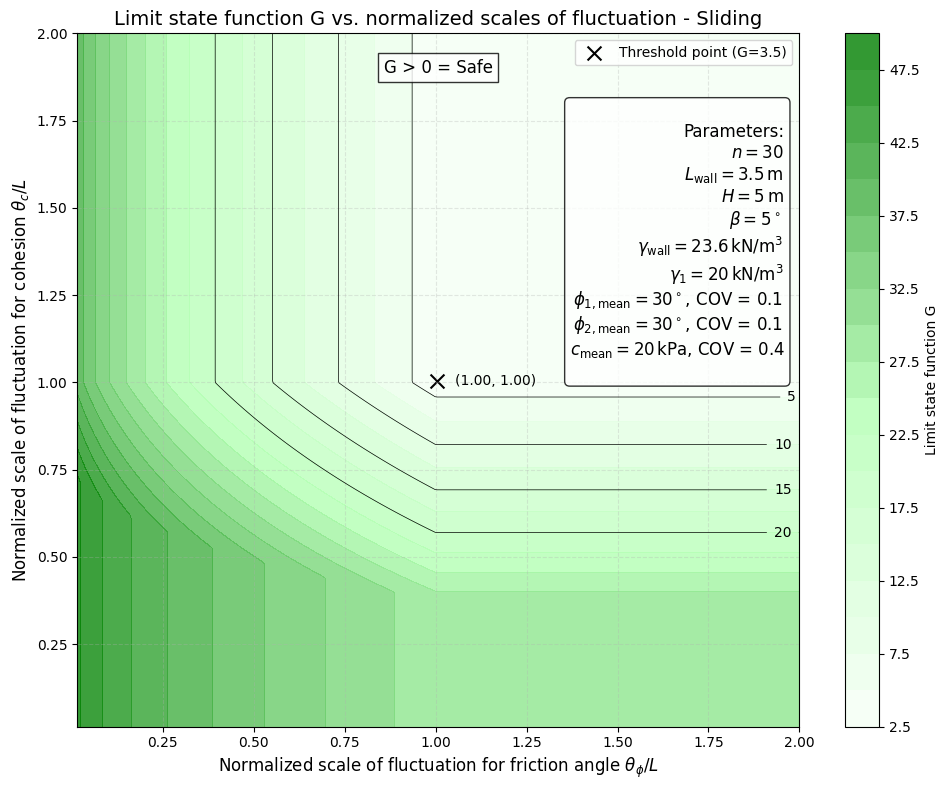

In [5]:
# Define parameter ranges
theta_phi_grid, theta_c_grid = np.meshgrid(theta_range, theta_range)

# Calculate G values for all combinations
G_values = np.zeros_like(theta_phi_grid)

L_infl = L_wall  

# Create normalized grids (theta/L)
theta_phi_normalized = theta_phi_grid / L_infl
theta_c_normalized = theta_c_grid / L_infl

for i in range(len(theta_range)):
    for j in range(len(theta_range)):
        G_values[i,j] = calculate_limit_state_function_G(
            theta_phi_grid[i,j], 
            theta_c_grid[i,j],
            n, L_wall, H, beta, gamma_wall, gamma1,
            phi1_mean, phi1_cov, phi2_mean, phi2_cov, c_mean, c_cov, case
        )

# Create the plot
plt.figure(figsize=(10, 8))

print(G_values)

# --- threshold Fix: Symmetric Normalization Around Zero ---
G_max = np.max(np.abs(G_values))  # Largest magnitude (positive or negative)
vmin, vmax = -G_max, G_max  # Ensures zero is centered in the colormap

# Create custom colormap: red (unsafe) -> white (G=0) -> green (safe)
colors = [
    (0.5, 0.0, 0.0),  # Deep red
    (1.0, 0.7, 0.7),  # Light red (near zero)
    (1, 1, 1),        # Pure white at zero
    (0.7, 1.0, 0.7),  # Light green (near zero)
    (0.0, 0.5, 0.0)   # Deep green
]
cmap_custom = LinearSegmentedColormap.from_list('danger_safe', colors, N=256)

# Create contour plot using normalized values
contour = plt.contourf(theta_phi_normalized, theta_c_normalized, G_values, 
                      levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
plt.colorbar(contour, label='Limit state function G')

# Add contour lines using normalized values
CS = plt.contour(theta_phi_normalized, theta_c_normalized, G_values, 
                levels=[-5, 0, 5, 10, 15, 20], colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

# Highlight the threshold point (minimum G) using normalized values
min_idx = np.unravel_index(np.argmin(G_values), G_values.shape)
x_coord = theta_phi_normalized[min_idx]
y_coord = theta_c_normalized[min_idx]

# Add text label with coordinate values near the marker
plt.text(x_coord + 0.05, y_coord, f'({x_coord:.2f}, {y_coord:.2f})', 
         color='black', fontsize=10, va='center')

plt.scatter(theta_phi_normalized[min_idx], theta_c_normalized[min_idx], 
           color='black', marker='x', s=100, label=f'Threshold point (G={G_values[min_idx]:.1f})')

# Formatting with normalized axis labels
plt.xlabel(r'Normalized scale of fluctuation for friction angle $\theta_\phi/L$', fontsize=12)
plt.ylabel(r'Normalized scale of fluctuation for cohesion $\theta_c/L$', fontsize=12)
plt.title('Limit state function G vs. normalized scales of fluctuation - Sliding', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

#legend
plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))


# Add text annotation about safety
plt.text(0.5, 0.95, 'G > 0 = Safe', transform=plt.gca().transAxes,
        ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

A Sensitivity Analysis on S1 and ST

                 ST   ST_conf
phi1_cov   0.028405  0.003905
phi2_cov   0.058775  0.009275
case       0.000000  0.000000
n          0.007764  0.001227
c_cov      0.046070  0.006068
theta_phi  0.017915  0.006060
theta_c    0.015889  0.005579
L_wall     0.788787  0.089117
H          0.083989  0.013392
                 S1   S1_conf
phi1_cov   0.026396  0.021964
phi2_cov   0.050493  0.032680
case       0.000000  0.000000
n          0.007644  0.010158
c_cov      0.045169  0.028192
theta_phi  0.012412  0.018205
theta_c    0.011592  0.013745
L_wall     0.745840  0.089809
H          0.053430  0.037579
                                 S2       S2_conf
(phi1_cov, phi2_cov)  -2.347188e-03  3.362256e-02
(phi1_cov, case)      -1.197371e-03  3.193350e-02
(phi1_cov, n)         -1.123148e-03  3.222668e-02
(phi1_cov, c_cov)     -9.062208e-04  3.190740e-02
(phi1_cov, theta_phi) -1.085487e-03  3.179063e-02
(phi1_cov, theta_c)   -6.748821e-04  3.161928e-02
(phi1_cov, L_wall)    -3.279093e-04  4.212107e-02


c:\Users\glori\anaconda3\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


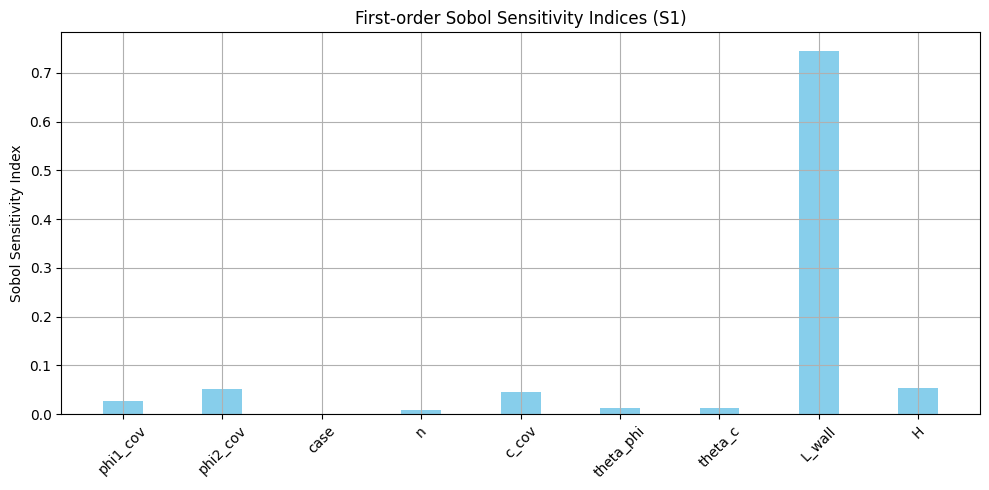

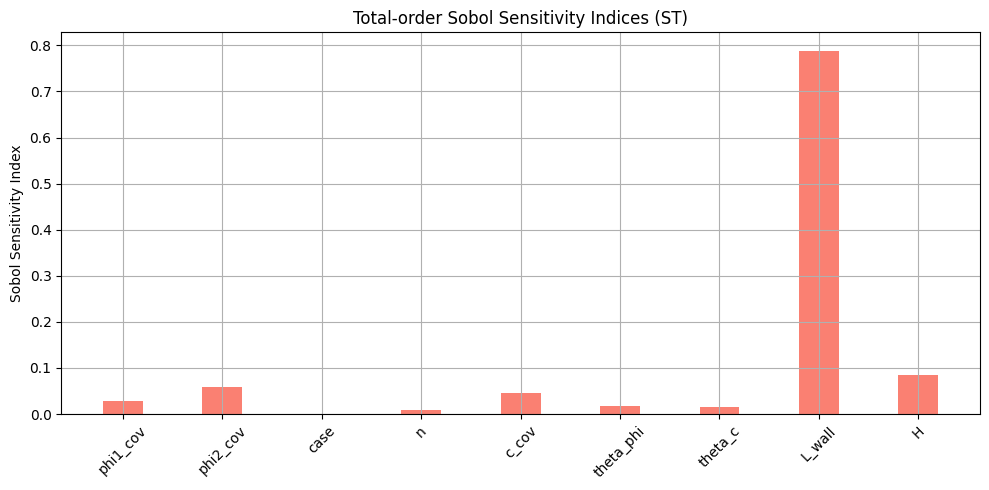

In [6]:
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol
import matplotlib.pyplot as plt

problem = {
    "num_vars": 9,
    "names": [
        "phi1_cov",
        "phi2_cov",
        "case", 
        "n",
        "c_cov",
        "theta_phi", 
        "theta_c",
        "L_wall",
        "H", 
    ],
    "bounds": [
        [0.05, 0.15], # by EC-7
        [0.05, 0.15],  # by EC-7
        [1, 3],
        [10, 30],
        [0.3, 0.5],   # by EC-7
        [1, 50],
        [1, 50], 
        [3,9],
        [4,7]
    ]
}

# --- Generate Sobol samples ---
N = 512  # base sample size
param_values = sobol_sample.sample(problem, N, calc_second_order=True)

# --- Evaluate the model for each sample ---
def evaluate_model(X):
    outputs = []
    for row in X:
        try:
            phi1_cov_SA, phi2_cov_SA, case_SA, n_SA, c_cov_SA, theta_phi_SA, theta_c_SA, L_wall_SA, H_SA = row
            case_SA = int(round(case_SA))
            n_SA = int(round(n_SA))
            
            G = calculate_limit_state_function_G(
                theta_phi_SA, theta_c_SA, n_SA, L_wall_SA, H_SA, beta, gamma_wall, gamma1,
                phi1_mean, phi1_cov_SA, phi2_mean, phi2_cov_SA, c_mean, c_cov_SA, case_SA
                )
            outputs.append(G)
        except:
            outputs.append(np.nan)
    return np.array(outputs)

Y = evaluate_model(param_values)
Y = np.nan_to_num(Y, nan=np.max(Y[np.isfinite(Y)]) + 1)  # Replace nan with large value

# --- Sobol analysis ---
Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=True)

# --- Plot S1 ---
fig1, ax1 = plt.subplots(figsize=(10, 5))
x_labels = problem["names"]
x = np.arange(len(x_labels))

ax1.bar(x, Si["S1"], width=0.4, label="First-order (S1)", color='skyblue')
ax1.set_ylabel("Sobol Sensitivity Index")
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=45)
ax1.set_title("First-order Sobol Sensitivity Indices (S1)")
ax1.grid(True)
plt.tight_layout()
plt.show()

# --- Plot ST ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.bar(x, Si["ST"], width=0.4, label="Total-order (ST)", color='salmon')
ax2.set_ylabel("Sobol Sensitivity Index")
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, rotation=45)
ax2.set_title("Total-order Sobol Sensitivity Indices (ST)")
ax2.grid(True)
plt.tight_layout()
plt.show()


A S2 sensitivity analysis.

In [7]:
# from matplotlib import cm
# import numpy as np

# # --- Plot S2 (Interaction Effects) ---
# fig3, ax3 = plt.subplots(figsize=(10, 8))

# # Get the S2 matrix
# S2_matrix = Si['S2']

# # Create a mask for the upper triangle (since the matrix is symmetric)
# mask = np.triu(np.ones_like(S2_matrix, dtype=bool))

# # Create a heatmap of the S2 values
# im = ax3.imshow(S2_matrix, cmap=cm.viridis, vmin=0, vmax=np.nanmax(S2_matrix))

# # Add colorbar
# cbar = fig3.colorbar(im, ax=ax3)
# cbar.set_label('Second-order Sobol Index')

# # Set ticks and labels
# ax3.set_xticks(np.arange(len(problem['names'])))
# ax3.set_yticks(np.arange(len(problem['names'])))
# ax3.set_xticklabels(problem['names'], rotation=45)
# ax3.set_yticklabels(problem['names'])

# # Add values to each cell
# for i in range(len(problem['names'])):
#     for j in range(len(problem['names'])):
#         if not mask[i,j]:  # Only show lower triangle
#             if not np.isnan(S2_matrix[i,j]):
#                 text = ax3.text(j, i, f"{S2_matrix[i,j]:.2f}",
#                               ha="center", va="center", color="w")

# ax3.set_title("Second-order Sobol Indices (Interaction Effects)")
# plt.tight_layout()
# plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


# --- Interactive Plot Function ---
theta_vals = theta_range
cov_vals = np.linspace(0.05, 0.5, 25)
L_vals = np.linspace(0.5, 7, 30)


def plot_Gleiten(
    vary='phi1_theta',
    L_infl=3.5,
    phi1_theta=5, phi1_cov=0.15,
    phi2_theta=5, phi2_cov=0.15,
    c_theta=5, c_cov=0.1,
    H=5):

    if vary == 'phi1_theta':
        x_vals = theta_vals
        x_label = r'$\theta_{\phi_1}$ (m)'
    elif vary == 'phi2_theta':
        x_vals = theta_vals
        x_label = r'$\theta_{\phi_2}$ (m)'
    elif vary == 'c_theta':
        x_vals = theta_vals
        x_label = r'$\theta_{c}$ (m)'
    elif vary == 'phi1_cov':
        x_vals = cov_vals
        x_label = r'CoV$_{\phi_1}$'
    elif vary == 'phi2_cov':
        x_vals = cov_vals
        x_label = r'CoV$_{\phi_2}$'
    elif vary == 'c_cov':
        x_vals = cov_vals
        x_label = r'CoV$_{c}$'
    elif vary == 'L_infl':
        x_vals = L_vals
        x_label = r'$L_{\text{infl}}$ (m)'
    elif vary == 'H':
        x_vals = np.linspace(1, 12, 25)
        x_label = r'Slope Height $H$ (m)'
    elif vary == 'B':
        x_vals = np.linspace(0.5, L_infl, 25)
        x_label = r'Base Width $B$ (m)'
    else:
        return

    G_vals = []

    for x in x_vals:
        phi1_theta_x = x if vary == 'phi1_theta' else phi1_theta
        # phi2_theta_x = x if vary == 'phi2_theta' else phi2_theta
        c_theta_x = x if vary == 'c_theta' else c_theta

        phi1_cov_x = x if vary == 'phi1_cov' else phi1_cov
        phi2_cov_x = x if vary == 'phi2_cov' else phi2_cov
        c_cov_x = x if vary == 'c_cov' else c_cov

        L_infl_x = x if vary == 'L_infl' else L_infl
        H_x = x if vary == 'H' else H
        #B_x = x if vary == 'B' else B

        try:
            G = calculate_limit_state_function_G(
                phi1_theta_x, c_theta_x, n, L_infl_x, H_x, beta, gamma_wall, gamma1,
                phi1_mean, phi1_cov_x, phi2_mean, phi2_cov_x, c_mean, c_cov_x,case
            )
            G_vals.append(G)
        except:
            G_vals.append(np.nan)

    G_vals = np.array(G_vals)
    min_idx = np.nanargmin(G_vals)
    x_crit = x_vals[min_idx]
    G_crit = G_vals[min_idx]

    plt.close('all')
    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, G_vals, marker='o', linestyle='-', color='indigo')
    plt.plot(x_crit, G_crit, 'ro', label=f'Min G = {G_crit:.2f}\n@ {x_label} = {x_crit:.2f}')
    plt.annotate(f'{G_crit:.2f} at {x_label} = {x_crit:.2f}',
                 xy=(x_crit, G_crit),
                 xytext=(x_crit + 0.05 * (x_vals[-1] - x_vals[0]), G_crit + 0.1),
                 arrowprops=dict(facecolor='red', arrowstyle='->'),
                 fontsize=10, color='red')

    plt.xlabel(x_label)
    plt.ylabel(r'Limit State Function $G$')
    plt.title(f'Effect of {x_label} on $G$ for Gleiten')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Interactive UI ---

interact_ui_gleiten = widgets.interactive(
    plot_Gleiten,
    vary=widgets.Dropdown(
        options=['phi1_theta', 'phi2_theta', 'c_theta',
                 'phi1_cov', 'phi2_cov', 'c_cov',
                 'L_infl', 'H'],
        value='phi1_theta',
        description='Vary:',
    ),
    L_infl=widgets.FloatSlider(min=0.5, max=10, step=0.1, value=3.5, description='L_infl'),
    H=widgets.FloatSlider(min=1, max=12, step=0.5, value=5, description='H (m)'),
    #B=widgets.FloatSlider(min=0.5, max=10, step=0.1, value=2, description='B (m)'),
    phi1_theta=widgets.FloatSlider(min=0.5, max=50, step=0.5, value=5, description='θ φ1'),
    phi1_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.15, description='CoV φ1'),
    phi2_theta=widgets.FloatSlider(min=0.5, max=50, step=0.5, value=5, description='θ φ2'),
    phi2_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.15, description='CoV φ2'),
    c_theta=widgets.FloatSlider(min=0.5, max=50, step=0.5, value=5, description='θ c'),
    c_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.1, description='CoV c'),
)

display(interact_ui_gleiten)


interactive(children=(Dropdown(description='Vary:', options=('phi1_theta', 'phi2_theta', 'c_theta', 'phi1_cov'…

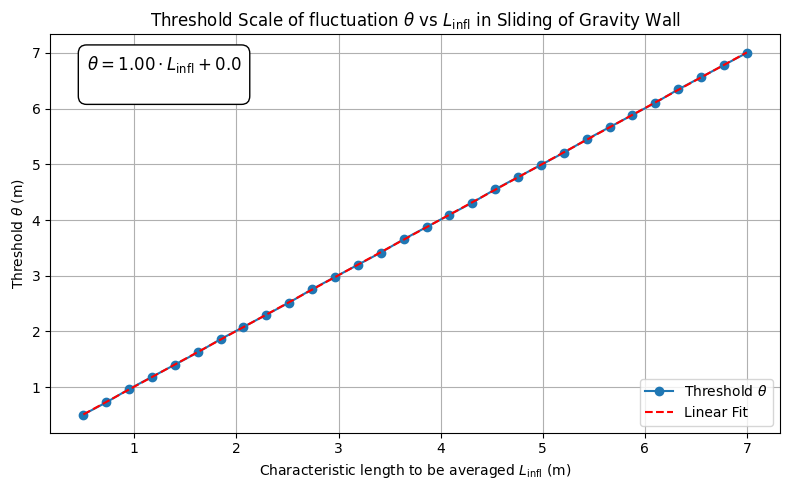

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from math import tan, atan, radians, degrees

threshold_theta_phi = []

for L_infl in L_vals:
    G_vals = []
    for theta in theta_vals:
        try:
            # Run Gleiten function directly with input means and covs
            G = calculate_limit_state_function_G(
                theta_phi=theta,
                theta_c=theta,
                n=n,
                L_wall=L_infl,
                H=H,
                beta=beta,
                gamma_wall=gamma_wall,
                gamma1=gamma1,
                phi1_mean=phi1_mean,
                phi1_cov=phi1_cov,
                phi2_mean=phi2_mean,
                phi2_cov=phi2_cov,
                c_mean=c_mean,
                c_cov=c_cov,
                case=case
            )
            G_vals.append(G)
        except:
            G_vals.append(np.nan)

    G_vals = np.array(G_vals)
    min_idx = np.nanargmin(G_vals)
    threshold_theta_phi.append(theta_vals[min_idx])

# --- Run and Plot ---
L_range = np.array(L_vals)
theta_phi_crit = np.array(threshold_theta_phi)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(L_range, theta_phi_crit)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(L_range, theta_phi_crit, 'o-', label='Threshold $\\theta$')
plt.plot(L_range, slope * L_range + intercept, 'r--', label='Linear Fit')

# Regression equation text
eq_text = (
    rf"$\theta= {slope:.2f} \cdot L_{{\mathrm{{infl}}}} + {intercept:.1f}$" "\n")

plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
)

# Labels and layout
plt.xlabel(r'Characteristic length to be averaged $L_{\mathrm{infl}}$ (m)')
plt.ylabel(r'Threshold $\theta$ (m)')
plt.title(r'Threshold Scale of fluctuation $\theta$ vs $L_{\mathrm{infl}}$ in Sliding of Gravity Wall')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
